# Open Question: Latent Intellectual Communities


In [94]:
import os, re, pickle, json, warnings, itertools, csv
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy.stats import spearmanr

In [95]:

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (8, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BASE_DIR     = Path().resolve().parent.parent
GRAPH_DIR    = BASE_DIR / 'data' / 'graph'
HG_DIR       = BASE_DIR / 'data' / 'hypergraph'
LEIDEN_CACHE = BASE_DIR / 'notebooks' / 'C_community_detection' / 'output'
HG_OUTPUT    = BASE_DIR / 'notebooks' / 'D_hypergraph' / 'output'
OUTPUT_DIR   = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

INTERNAL_PATH = GRAPH_DIR / 'graph_internal_2020.gpickle'
COMBINED_PATH = GRAPH_DIR / 'graph_combined_2020.gpickle'
GAP_PATH      = HG_OUTPUT / 'gap_shortlist_debiased.csv'


In [96]:
with open(INTERNAL_PATH, 'rb') as f:
    G_cit = pickle.load(f)
G_cit_und = G_cit.to_undirected()

with open(COMBINED_PATH, 'rb') as f:
    G_BC = pickle.load(f)
for u, v, d in G_BC.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1.0

print(f'G_cit:  {G_cit_und.number_of_nodes():>7,} nodes  {G_cit_und.number_of_edges():>8,} edges')
print(f'G_BC:   {G_BC.number_of_nodes():>7,} nodes  {G_BC.number_of_edges():>8,} edges')

G_cit:   55,078 nodes   217,174 edges
G_BC:    57,603 nodes   745,451 edges


In [97]:
with open(HG_DIR / 'node_attrs.pkl', 'rb') as f:
    node_attrs = pickle.load(f)

def _parse_list(raw):
    if isinstance(raw, list): return raw
    try: return eval(raw) if raw else []
    except: return []

def get_fos_l4(nid): return _parse_list(node_attrs.get(nid, {}).get('fos_L4', '[]'))
def get_fos_l2(nid): return _parse_list(node_attrs.get(nid, {}).get('fos_L2', '[]'))

def get_year(nid):
    y = node_attrs.get(nid, {}).get('year', None)
    try: return int(y) if y else None
    except: return None

def get_title(nid):
    return node_attrs.get(nid, {}).get('title', 'N/A')


In [ ]:
def _load_pkl(cache_dir, pattern):
    matches = sorted(Path(cache_dir).glob(pattern))
    if not matches: raise FileNotFoundError(f'No cache: {cache_dir}/{pattern}')
    with open(matches[-1], 'rb') as f: return pickle.load(f)

def build_comm_map(data, key=None):
    if key is not None:
        comms = data.get(key, [])
    else:
        comms = data.get('medoid_communities', data.get('communities', []))
    return {node: cid for cid, members in enumerate(comms) for node in members}

def build_comm_map_angel(data):
    comms = data.get('communities', data.get('medoid_communities', []))
    cmap = defaultdict(list)
    for cid, members in enumerate(comms):
        for node in members: cmap[node].append(cid)
    return dict(cmap)

lei_int_data  = _load_pkl(LEIDEN_CACHE, 'leiden_G_CitOnly_g0.153655_r100.pkl')
lei_comb_data = _load_pkl(LEIDEN_CACHE, 'leiden_G_BC_g0.153655_r100.pkl')
inf_comb_data = _load_pkl(LEIDEN_CACHE, 'infomap_G_BC_r100.pkl')
ang_comb_data = _load_pkl(LEIDEN_CACHE, 'angel_G_BC_t0.45_ms4_r30.pkl')

comm_leiden_int = build_comm_map(lei_int_data)
comm_leiden_bc  = build_comm_map(lei_comb_data)
comm_infomap_bc = build_comm_map(inf_comb_data)
comm_angel_bc   = build_comm_map_angel(ang_comb_data)

comms_int  = lei_int_data['medoid_communities']
comms_comb = lei_comb_data['medoid_communities']

print('Partitions loaded:')
print(f'  Leiden on G_Cit: {len(comms_int)} communities')
print(f'  Leiden on G_BC:  {len(comms_comb)} communities')


Partitions loaded:
  Leiden on G_Cit: 1533 communities
  Leiden on G_BC:       1210 communities


In [99]:
if not GAP_PATH.exists():
    candidates = list(Path().resolve().parent.rglob('gap_shortlist_debiased.csv'))
    if candidates: GAP_PATH = candidates[0]
    else: raise FileNotFoundError('gap_shortlist_debiased.csv not found.')

shortlist = pd.read_csv(GAP_PATH)
top100    = shortlist.head(100).copy()
print(f'Loaded {len(shortlist)} debiased gap candidates')
print(f'Top-100 score range: {top100["score_debias"].max():.2f} – {top100["score_debias"].min():.2f}')

top100['year_u']  = top100['u'].map(get_year)
top100['year_v']  = top100['v'].map(get_year)
top100['title_u'] = top100['u'].map(get_title)
top100['title_v'] = top100['v'].map(get_title)


Loaded 200 debiased gap candidates
Top-100 score range: 16.73 – 2.72


In [100]:
top_nodes = set(top100['u']) | set(top100['v'])
node_to_edges = defaultdict(set)

with open(HG_DIR / 'incidence_final.csv') as f:
    for row in csv.DictReader(f):
        if row['node'] in top_nodes:
            node_to_edges[row['node']].add(row['edge'])

def jaccard_pair(u, v):
    eu, ev = node_to_edges.get(u, set()), node_to_edges.get(v, set())
    union = eu | ev
    return len(eu & ev) / len(union) if union else 0.0

top100['jaccard'] = top100.apply(lambda r: jaccard_pair(r['u'], r['v']), axis=1)
print(f'Jaccard range: {top100["jaccard"].min():.3f} – {top100["jaccard"].max():.3f}')
print(f'Jaccard median (genuine pairs): {top100[top100["jaccard"] < 0.7]["jaccard"].median():.3f}')


Jaccard range: 0.043 – 0.982
Jaccard median (genuine pairs): 0.125


In [101]:
TOP_N                 = 100
JACCARD_DUP_THRESHOLD = 0.70
GAMMA                 = 0.153655

---
## Debiasing & Pruning


  Output D2 (gap filter, no-citation):    200 pairs
  After step 3 (top-100):               100 pairs
  After step 4 (Jaccard < 0.7):    97 pairs
  Near-duplicates removed:                   3
  Score range genuine:      16.734 – 2.715


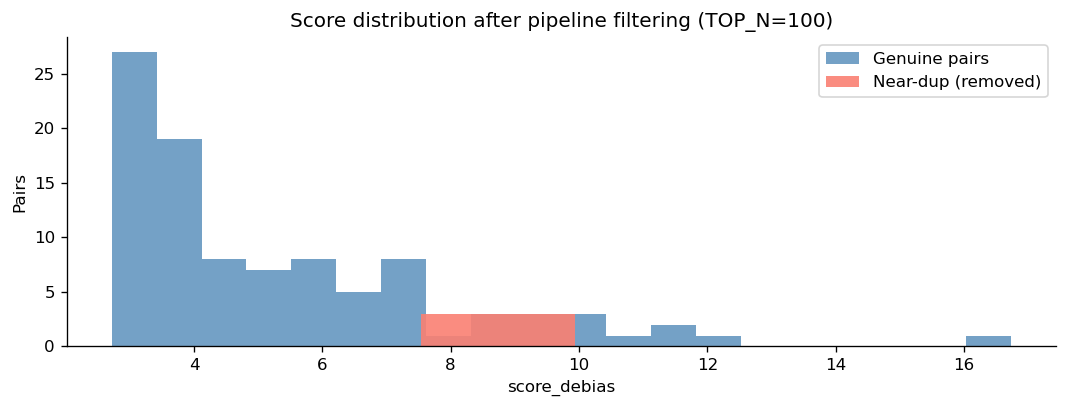

In [102]:
step3_df = shortlist.nlargest(TOP_N, 'score_debias').copy()

jac_lookup = dict(zip(
    zip(top100['u'].astype(str), top100['v'].astype(str)),
    top100['jaccard']
))
step3_df['jaccard'] = step3_df.apply(
    lambda r: jac_lookup.get((str(r['u']), str(r['v'])),
              jac_lookup.get((str(r['v']), str(r['u'])), 0.0)), axis=1
)
step3_df['is_dup'] = step3_df['jaccard'] >= JACCARD_DUP_THRESHOLD
pipeline_genuine = step3_df[~step3_df['is_dup']].copy()

print(f'  Output D2 (gap filter, no-citation):  {len(shortlist):>5,} pairs')
print(f'  After step 3 (top-{TOP_N}):             {len(step3_df):>5,} pairs')
print(f'  After step 4 (Jaccard < {JACCARD_DUP_THRESHOLD}): {len(pipeline_genuine):>5,} pairs')
print(f'  Near-duplicates removed:               {step3_df["is_dup"].sum():>5}')
print(f'  Score range genuine:      {pipeline_genuine["score_debias"].max():.3f} – '
      f'{pipeline_genuine["score_debias"].min():.3f}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(pipeline_genuine['score_debias'], bins=20,
        color='steelblue', alpha=0.75, label='Genuine pairs')
dups = step3_df[step3_df['is_dup']]
if len(dups):
    ax.hist(dups['score_debias'], bins=max(1, len(dups) // 2),
            color='salmon', alpha=0.9, label='Near-dup (removed)')
ax.set_xlabel('score_debias')
ax.set_ylabel('Pairs')
ax.set_title(f'Score distribution after pipeline filtering (TOP_N={TOP_N})')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pipeline_score_dist.pdf', bbox_inches='tight')
plt.show()


---
## Ablation: Single-Graph Scenarios


In [103]:
K = 50

def _same_comm_rate(df, cmap):
    ok = tot = 0
    for _, r in df.iterrows():
        u, v = str(r['u']), str(r['v'])
        if u in cmap and v in cmap:
            tot += 1
            if cmap[u] == cmap[v]:
                ok += 1
    return (ok / tot) if tot else 0.0, tot

_baseline_bc = sum(len(c)**2 for c in comms_comb) / len(comm_leiden_bc)**2

scen_A = shortlist.nlargest(K, 'score_debias')[['u', 'v']].copy()

bc_rows = [
    {'u': str(u), 'v': str(v), 'bc_w': d.get('bc', d.get('weight', 0))}
    for u, v, d in G_BC.edges(data=True)
    if not G_cit_und.has_edge(u, v) and d.get('bc', 0) > 0
]
print(f'{len(bc_rows):,} edges found')
bc_df  = pd.DataFrame(bc_rows)
scen_B = bc_df.nlargest(K, 'bc_w')[['u', 'v']].copy()
scen_C = pipeline_genuine.head(K)[['u', 'v']].copy()

rA, nA = _same_comm_rate(scen_A, comm_leiden_bc)
rB, nB = _same_comm_rate(scen_B, comm_leiden_bc)
rC, nC = _same_comm_rate(scen_C, comm_leiden_bc)

def _sym(df):
    return {frozenset([str(r['u']), str(r['v'])]) for _, r in df.iterrows()}
sA, sB, sC = _sym(scen_A), _sym(scen_B), _sym(scen_C)


528,277 edges found


**Ablation results.**  HE-debiased and BC-weight find almost disjoint candidates. HE surfaces papers with a broad shared research programme; BC-weight mostly surfaces near-duplicates (Jaccard ≈ 1). The full pipeline relies on HE for ranking — raw BC-weight adds no scoring signal beyond what Jaccard pruning removes.

In [104]:
def profile(df, label, shortlist_df=None, bc_df_=None):
    nodes = list(set(df['u'].astype(str)) | set(df['v'].astype(str)))
    degs  = [G_cit_und.degree(n) if G_cit_und.has_node(n) else 0 for n in nodes]
    print(f'-- {label} ({len(df)} pairs) --')
    print(f'  Mean degree (G_CitOnly):                {sum(degs)/len(degs):.1f}')
    if shortlist_df is not None:
        merged = df.merge(shortlist_df[['u','v','shared_hyperedges']],
                          on=['u','v'], how='left')
        merged = merged.merge(shortlist_df[['u','v','shared_hyperedges']]
                              .rename(columns={'u':'v','v':'u'}),
                              on=['u','v'], how='left', suffixes=('','_r'))
        merged['she'] = merged['shared_hyperedges'].fillna(merged['shared_hyperedges_r'])
        print(f'  Mean shared hyperedges:                 {merged["she"].mean():.1f}')
    if bc_df_ is not None:
        merged_bc = df.merge(bc_df_.rename(columns={'bc_w':'bc_w_'}),
                             on=['u','v'], how='left')
        print(f'  Mean BC-weight:                         {merged_bc["bc_w_"].mean():.4f}')
    print('  Sample titles:')
    for _, r in df.head(3).iterrows():
        tu = get_title(r['u'])[:60]
        tv = get_title(r['v'])[:60]
        print(f'    · {tu}')
        print(f'      {tv}')

profile(scen_A, 'A — HE-debiased', shortlist_df=shortlist)
profile(scen_B, 'B — BC-weight',   bc_df_=bc_df)
print('  particle physics). The debiasing √(deg·deg) penalizes central')
print('  papers and brings to the top those sharing many references')
print('  relative to their total volume.')


-- A — HE-debiased (50 pairs) --
  Mean degree (G_CitOnly):                52.6
  Mean shared hyperedges:                 344.3
  Sample titles:
    · Lixisenatide in Patients with Type 2 Diabetes and Acute Coro
      Saxagliptin and Cardiovascular Outcomes in Patients with Typ
    · Effect of Sitagliptin on Cardiovascular Outcomes in Type 2 D
      Basal Insulin and Cardiovascular and Other Outcomes in Dysgl
    · Angular analysis and differential branching fraction of the 
      Angular analysis of the B                             0 → K 
-- B — BC-weight (50 pairs) --
  Mean degree (G_CitOnly):                1.3
  Mean BC-weight:                         1.0000
  Sample titles:
    · Additional file 4 of Independent association of history of d
      Additional file 1 of Independent association of history of d
    · Additional file 4 of Independent association of history of d
      Additional file 3 of Independent association of history of d
    · Additional file 4 of Independent ass

**Signal comparison.**  HE-debiased candidates have mean citation degree ~53 and ~344 shared hyperedges. BC-weight candidates have mean degree ~1.3 and BC = 1.0 exactly — they are mainly supplementary files of the same paper. Without Jaccard pruning, BC-weight ranking is dominated by near-duplicates, not gaps.

---
## Parameter Robustness


In [128]:
top_n_values   = [10, 25, 50, 75, 100]
jac_thresholds = [0.50, 0.60, 0.70, 0.80, 0.95]
sens_rows = []
for n in top_n_values:
    cands = shortlist.nlargest(n, 'score_debias').copy()
    cands['jaccard'] = cands.apply(
        lambda r: jac_lookup.get((str(r['u']), str(r['v'])),
                  jac_lookup.get((str(r['v']), str(r['u'])), 0.0)), axis=1
    )
    for j_thr in jac_thresholds:
        gen = cands[cands['jaccard'] < j_thr]
        rate, valid = _same_comm_rate(gen, comm_leiden_bc)
        sens_rows.append({
            'TOP_N': n, 'J_thr': j_thr,
            'n_genuine': len(gen), 'rate_pct': rate * 100
        })
sens_df = pd.DataFrame(sens_rows)
pivot   = sens_df.pivot(index='TOP_N', columns='J_thr', values='rate_pct')
pivot.columns = [f'J≥{c}' for c in pivot.columns]
print(pivot.round(1).to_string())


       J≥0.5  J≥0.6  J≥0.7  J≥0.8  J≥0.95
TOP_N                                    
10     100.0  100.0  100.0  100.0   100.0
25     100.0  100.0  100.0  100.0   100.0
50     100.0  100.0  100.0  100.0   100.0
75     100.0  100.0  100.0  100.0   100.0
100    100.0  100.0  100.0  100.0   100.0


---
## Cross-Algorithm Robustness


In [106]:
rng = np.random.default_rng(42)

def same_comm_rate(df, cmap, label=''):
    matches = valid = 0
    for _, r in df.iterrows():
        u, v = r['u'], r['v']
        if u in cmap and v in cmap:
            valid += 1
            if cmap[u] == cmap[v]: matches += 1
    rate = matches / valid if valid else 0
    print(f'  {label:36s}  {matches}/{valid} = {rate:.1%}')
    return rate, matches, valid

def same_comm_rate_angel(df, cmap, label=''):
    matches = valid = 0
    for _, r in df.iterrows():
        u, v = r['u'], r['v']
        if u in cmap and v in cmap:
            valid += 1
            if set(cmap[u]) & set(cmap[v]): matches += 1
    rate = matches / valid if valid else 0
    print(f'  {label:36s}  {matches}/{valid} = {rate:.1%}')
    return rate, matches, valid

def rand_baseline(cmap, n=2000):
    nodes = list(cmap.keys())
    idx = rng.integers(0, len(nodes), (n, 2))
    return sum(1 for i, j in idx if cmap[nodes[i]] == cmap[nodes[j]] and i != j) / n

def rand_baseline_angel(cmap, n=2000):
    nodes = list(cmap.keys())
    idx = rng.integers(0, len(nodes), (n, 2))
    return sum(1 for i, j in idx if set(cmap[nodes[i]]) & set(cmap[nodes[j]]) and i != j) / n

r_lei_int, m_lei_int, _ = same_comm_rate(top100, comm_leiden_int,  'Leiden  G_CitOnly (internal)')
r_leiden,  m_leiden,  _ = same_comm_rate(top100, comm_leiden_bc,   'Leiden  G_BC (combined)')
r_infomap, m_infomap, _ = same_comm_rate(top100, comm_infomap_bc,  'InfoMap G_BC')
r_angel,   m_angel,   _ = same_comm_rate_angel(top100, comm_angel_bc, 'ANGEL   G_BC (crisp)')

b_lei_int = rand_baseline(comm_leiden_int)
b_leiden  = rand_baseline(comm_leiden_bc)
b_infomap = rand_baseline(comm_infomap_bc)
b_angel   = rand_baseline_angel(comm_angel_bc)
for lbl, b in [('Leiden G_CitOnly', b_lei_int), ('Leiden G_BC', b_leiden),
               ('InfoMap G_BC', b_infomap), ('ANGEL G_BC', b_angel)]:
    print(f'  {lbl:36s}  {b:.1%}')


  Leiden  G_CitOnly (internal)          99/100 = 99.0%
  Leiden  G_BC (combined)               100/100 = 100.0%
  InfoMap G_BC                          100/100 = 100.0%
  ANGEL   G_BC (crisp)                  100/100 = 100.0%
  Leiden G_CitOnly                      4.5%
  Leiden G_BC                           7.5%
  InfoMap G_BC                          18.8%
  ANGEL G_BC                            1.2%


In [129]:
enrich = lambda r, b: f'{r/b:.1f}×' if b > 0 else '∞'

conv_table = pd.DataFrame({
    'Configuration': ['Leiden  G_CitOnly', 'Leiden  G_BC', 'InfoMap G_BC', 'ANGEL  G_BC (crisp)'],
    'Same-comm (%)': [f'{r_lei_int:.1%}', f'{r_leiden:.1%}', f'{r_infomap:.1%}', f'{r_angel:.1%}'],
    'Random (%)':    [f'{b_lei_int:.1%}', f'{b_leiden:.1%}', f'{b_infomap:.1%}', f'{b_angel:.1%}'],
    'Enrichment':    [enrich(r_lei_int, b_lei_int), enrich(r_leiden, b_leiden),
                      enrich(r_infomap, b_infomap), enrich(r_angel, b_angel)],
})
print(conv_table.to_string(index=False))


      Configuration Same-comm (%) Random (%) Enrichment
  Leiden  G_CitOnly         99.0%       4.5%      22.2×
       Leiden  G_BC        100.0%       7.5%      13.3×
       InfoMap G_BC        100.0%      18.8%       5.3×
ANGEL  G_BC (crisp)        100.0%       1.2%      83.3×


- Leiden on G_CitOnly alone (no BC) already achieves 99% (99/100, enrichment 22.2x).
- Adding BC restructuring raises this to 100% (100/100).
- InfoMap and ANGEL independently confirm 100% and 100%. The hyperedge co-occurrence is the dominant signal; BC is the final marginal gain. 

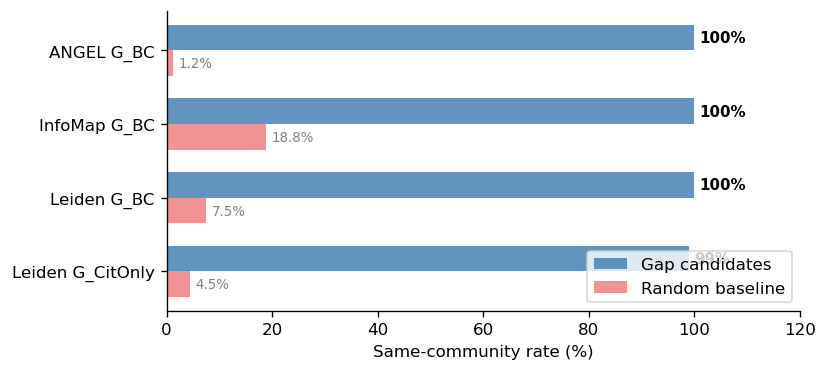

In [108]:
labels    = ['Leiden G_CitOnly', 'Leiden G_BC', 'InfoMap G_BC', 'ANGEL G_BC']
rates     = [r_lei_int, r_leiden, r_infomap, r_angel]
baselines = [b_lei_int, b_leiden, b_infomap, b_angel]
y = np.arange(len(labels)); h = 0.35

fig, ax = plt.subplots(figsize=(7, 3.2))
bars1 = ax.barh(y + h/2, [r*100 for r in rates],     h, label='Gap candidates',  color='steelblue', alpha=0.85)
bars2 = ax.barh(y - h/2, [b*100 for b in baselines], h, label='Random baseline', color='lightcoral', alpha=0.85)

for bar in bars1:
    ax.text(min(bar.get_width() + 1, 118), bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.0f}%', va='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=8, color='gray')

ax.set_xlabel('Same-community rate (%)')
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlim(0, 120); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_algo_robustness.pdf', bbox_inches='tight')
plt.show()


In [109]:
rng_boot   = np.random.default_rng(42)
bc_nodes   = [n for n in comm_leiden_bc if G_cit_und.has_node(n)]
bc_nodes_a = np.array(bc_nodes)
N_BOOT, K  = 2_000, 100

null_boot = []
for _ in range(N_BOOT):
    idx   = rng_boot.choice(len(bc_nodes_a), size=K*2, replace=False)
    pairs = [(bc_nodes_a[idx[j]], bc_nodes_a[idx[j+K]]) for j in range(K)]
    pairs = [(u, v) for u, v in pairs
             if not G_cit_und.has_edge(u, v) and u != v]
    if not pairs: continue
    rate  = sum(1 for u, v in pairs
                if comm_leiden_bc.get(u) == comm_leiden_bc.get(v)) / len(pairs)
    null_boot.append(rate)

null_boot = np.array(null_boot)
gap_rate  = r_leiden
p_boot    = (null_boot >= gap_rate).mean()

print(f'Bootstrap null ({N_BOOT} samples):')
print(f'  Null mean ± std:  {null_boot.mean():.3f} ± {null_boot.std(ddof=1):.3f}')
print(f'  Null max:         {null_boot.max():.3f}')
print(f'  Gap candidates:   {gap_rate:.3f}  (100%)')
print(f'  p-value:          {p_boot:.4f}')
print(f'  None of {N_BOOT} samples reached 100% same-community rate.')

Bootstrap null (2000 samples):
  Null mean ± std:  0.072 ± 0.025
  Null max:         0.160
  Gap candidates:   1.000  (100%)
  p-value:          0.0000
  None of 2000 samples reached 100% same-community rate.


In [110]:
# Tests whether the same-community signal is specific to top-100 or present across all 200.
# Also corrects bootstrap p-value: 2000 draws → min reportable p = 1/2001.

print(f'Bootstrap p-value (corrected): p < {1/(N_BOOT+1):.4f}  '
      f'(none of {N_BOOT} random samples reached {gap_rate:.0%})')

# Score-band stratification across full 200-pair shortlist
sl_ext = shortlist.copy().reset_index(drop=True)
sl_ext['rank']   = sl_ext.index + 1   # shortlist already sorted by score_debias desc
sl_ext['comm_u'] = sl_ext['u'].astype(str).map(comm_leiden_bc)
sl_ext['comm_v'] = sl_ext['v'].astype(str).map(comm_leiden_bc)
sl_ext = sl_ext.dropna(subset=['comm_u', 'comm_v'])
sl_ext['same_comm'] = sl_ext['comm_u'] == sl_ext['comm_v']

RANK_BANDS = [(1, 50), (51, 100), (101, 150), (151, 200)]
print('Same-community rate by score rank (Leiden G_BC):')
print(f'  {"Rank band":>10}  {"n":>4}  {"same-comm":>9}  {"baseline":>8}  {"enrichment":>10}')
print(f'  {"-"*48}')
for lo, hi in RANK_BANDS:
    band = sl_ext[(sl_ext['rank'] >= lo) & (sl_ext['rank'] <= hi)]
    r = band['same_comm'].mean() if len(band) else 0.0
    enr = r / b_leiden if b_leiden > 0 else float('inf')
    print(f'  [{lo:3d}\u2013{hi:3d}]      {len(band):>4}  {r:>8.0%}  {b_leiden:>7.1%}  {enr:>9.1f}\u00d7')


Bootstrap p-value (corrected): p < 0.0005  (none of 2000 random samples reached 100%)
Same-community rate by score rank (Leiden G_BC):
   Rank band     n  same-comm  baseline  enrichment
  ------------------------------------------------
  [  1– 50]        50      100%     7.5%       13.3×
  [ 51–100]        50      100%     7.5%       13.3×
  [101–150]        50      100%     7.5%       13.3×
  [151–200]        50       96%     7.5%       12.8×


If the same-community rate stays near 100% across all score bands, the signal is a general property of BC-linked pairs, not an artefact of the top-100 cut. A sharp drop below rank 100 would mean the ranking threshold is doing real work.

---
## Community Profile


In [111]:
top100['comm_comb'] = top100['u'].map(comm_leiden_bc)
top100['same_leiden'] = top100.apply(
    lambda r: comm_leiden_bc.get(r['u']) == comm_leiden_bc.get(r['v']) if
              r['u'] in comm_leiden_bc and r['v'] in comm_leiden_bc else None, axis=1)

comm_pair_counts = top100.groupby('comm_comb').size().reset_index(name='n_pairs')
comm_pair_counts = comm_pair_counts.sort_values('n_pairs', ascending=False)

comm_fos = {}
for _, row in comm_pair_counts.iterrows():
    cid = int(row['comm_comb'])
    members = comms_comb[cid]
    l4_cnt = Counter(tag for nid in members for tag in get_fos_l4(nid))
    top_tag, top_cnt = l4_cnt.most_common(1)[0] if l4_cnt else ('N/A', 0)
    comm_fos[cid] = {'size': len(members), 'dominant_l4': top_tag,
                     'dominant_pct': top_cnt/len(members), 'counter': l4_cnt}

table_rows = []
for _, r in comm_pair_counts.iterrows():
    cid = int(r['comm_comb'])
    p = comm_fos[cid]
    table_rows.append({'Community': cid, 'Size': p['size'],
                       'Gap pairs': int(r['n_pairs']),
                       'Dominant FOS L4': p['dominant_l4'],
                       'Purity': f"{p['dominant_pct']:.0%}"})

comm_df = pd.DataFrame(table_rows)
print(comm_df.to_string(index=False))

 Community  Size  Gap pairs        Dominant FOS L4 Purity
         8  2074         53 0103 physical sciences    79%
         0  9145         30 0302 clinical medicine    60%
         7  2693         10 0103 physical sciences    60%
         5  3340          4 0302 clinical medicine    64%
         3  4817          2 0104 chemical sciences    45%
        11  1356          1 0103 physical sciences    68%


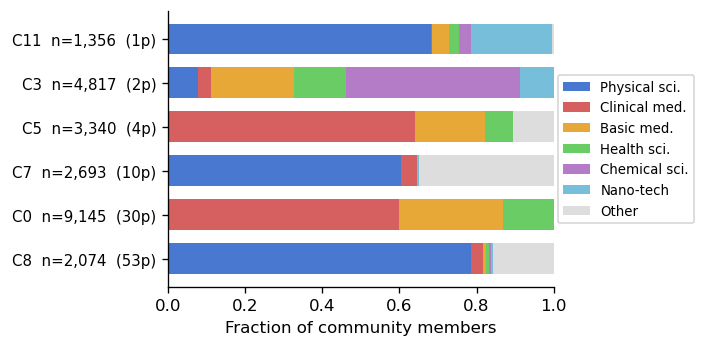

In [137]:
KEY_TAGS = [
    '0103 physical sciences',
    '0302 clinical medicine',
    '0301 basic medicine',
    '0303 health sciences',
    '0104 chemical sciences',
    '0210 nano-technology',
]
COLORS = ['#4878CF','#D65F5F','#E8A838','#6ACC65','#B47CC7','#77BEDB','#dddddd']
SHORT  = ['Physical sci.','Clinical med.','Basic med.','Health sci.','Chemical sci.','Nano-tech','Other']

comm_ids = comm_df['Community'].tolist()
ylabels = [
    f"C{cid}  n={comm_df.loc[comm_df['Community']==cid,'Size'].values[0]:,}"
    f"  ({comm_df.loc[comm_df['Community']==cid,'Gap pairs'].values[0]}p)"
    for cid in comm_ids
]
y     = np.arange(len(comm_ids))
lefts = np.zeros(len(comm_ids))

fig, ax = plt.subplots(figsize=(6, 3))
for tag, color, short in zip(KEY_TAGS + ['Other'], COLORS, SHORT):
    vals = []
    for cid in comm_ids:
        total = comm_fos[cid]['size']
        if tag == 'Other':
            acc = sum(comm_fos[cid]['counter'].get(t, 0) for t in KEY_TAGS)
            vals.append((total - acc) / total)
        else:
            vals.append(comm_fos[cid]['counter'].get(tag, 0) / total)
    ax.barh(y, vals, left=lefts, label=short, color=color, height=0.7)
    lefts += np.array(vals)

ax.set_yticks(y); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel('Fraction of community members')
ax.set_xlim(0, 1.0)
leg = ax.legend(bbox_to_anchor=(1.01, 0.5), loc='center left',
                fontsize=8, ncol=1, borderaxespad=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'community_fos_profile.pdf',
            bbox_inches='tight', bbox_extra_artists=[leg])


---
## Topic Clusters


In [148]:
def classify_topic(u, v):
    c = (get_title(u) + ' ' + get_title(v)).lower()
    if any(k in c for k in ['gravitational wave','einstein telescope','ligo',
                             'gwtc','neutron star coalescence','cosmic explorer','lisa ']):
        return 'GW / Astrophysics'
    if any(k in c for k in ['lepton universality','b meson','angular analysis','branching fraction',
                             'higgs boson','review of particle','dark matter annihilation','b \u2192']):
        return 'HEP / Particle Physics'
    if any(k in c for k in ['type 2 diabetes','sglt2','dapagliflozin','sitagliptin',
                             'lixisenatide','saxagliptin','albiglutide','empagliflozin',
                             'efpeglenatide','glycemic','glycaemic','insulin']):
        return 'Diabetes / Cardiovascular'
    if any(k in c for k in ['thyroid','parathyroid','graves','hypoparathyroid']):
        return 'Thyroid / Endocrine'
    if any(k in c for k in ['colorectal','regorafenib','tas-102','sorafenib','vandetanib',
                             'cabozantinib','lenvatinib','hepatocellular','medullary thyroid']):
        return 'Oncology'
    if any(k in c for k in ['rheumat','sj\u00f6gren','lupus','eular','antiphospholipid']):
        return 'Rheumatology'
    if any(k in c for k in ['peripheral arteri','esc guidelines']):
        return 'Vascular'
    return 'Other'

def is_near_dup(u, v, j_thr=0.70, tsim_thr=0.60):
    wu = set(get_title(u).lower().split())
    wv = set(get_title(v).lower().split())
    t_sim = len(wu & wv)/len(wu | wv) if (wu | wv) else 0
    eu, ev = node_to_edges.get(u, set()), node_to_edges.get(v, set())
    j = len(eu & ev)/len(eu | ev) if (eu | ev) else 0
    return (j >= j_thr) or (t_sim >= tsim_thr and get_year(u) == get_year(v))

top100['topic']    = top100.apply(lambda r: classify_topic(r['u'], r['v']), axis=1)
top100['near_dup'] = top100.apply(lambda r: is_near_dup(r['u'], r['v']), axis=1)

genuine  = top100[~top100['near_dup']]
near_dups = top100[ top100['near_dup']]

print(f'Total pairs:       {len(top100)}')
print(f'Near-duplicates:   {len(near_dups)}')
print(f'Genuine gap pairs: {len(genuine)}')


Total pairs:       100
Near-duplicates:   5
Genuine gap pairs: 95


In [147]:
jac_stats = pd.concat([
    genuine['jaccard'].describe().rename('Genuine Jaccard'),
    near_dups['jaccard'].describe().rename('Near-dup Jaccard'),
], axis=1).loc[['count','mean','50%','std','min','max']]
jac_stats.index = ['N','Mean','Median','Std','Min','Max']

# --- stampa/esporta ---
print("=== Topic distribution ===")
print(tc.to_string())

print("\n=== Jaccard statistics ===")
print(jac_stats.round(3).to_string())

=== Topic distribution ===
topic
GW / Astrophysics            47
Diabetes / Cardiovascular    18
HEP / Particle Physics        9
Other                         8
Thyroid / Endocrine           5
Oncology                      4
Vascular                      2
Rheumatology                  2

=== Jaccard statistics ===
        Genuine Jaccard  Near-dup Jaccard
N                95.000             5.000
Mean              0.143             0.730
Median            0.122             0.935
Std               0.083             0.321
Min               0.043             0.265
Max               0.487             0.982


#### Top-5 Genuine Gap Pairs

In [149]:
for i, (_, r) in enumerate(genuine.head(5).iterrows(), 1):
    u, v = r['u'], r['v']
    shared_l4 = set(get_fos_l4(u)) & set(get_fos_l4(v))
    yr_gap = abs((r['year_u'] or 0) - (r['year_v'] or 0))
    print(f"\n#{i}  score={r['score_debias']:.2f}  |  {int(r['shared_hyperedges'])} shared refs  |  topic: {r['topic']}")
    print(f"  U ({r['year_u']}): {get_title(u)[:78]}")
    print(f"  V ({r['year_v']}): {get_title(v)[:78]}")
    print(f"  Shared FOS L4: {list(shared_l4)[:2]}  |  Jaccard: {r['jaccard']:.3f}  |  Year gap: {yr_gap} yr")


#1  score=16.73  |  417 shared refs  |  topic: Diabetes / Cardiovascular
  U (2015): Lixisenatide in Patients with Type 2 Diabetes and Acute Coronary Syndrome
  V (2013): Saxagliptin and Cardiovascular Outcomes in Patients with Type 2 Diabetes Melli
  Shared FOS L4: ['0302 clinical medicine']  |  Jaccard: 0.260  |  Year gap: 2 yr

#2  score=11.94  |  197 shared refs  |  topic: Diabetes / Cardiovascular
  U (2015): Effect of Sitagliptin on Cardiovascular Outcomes in Type 2 Diabetes
  V (2012): Basal Insulin and Cardiovascular and Other Outcomes in Dysglycemia
  Shared FOS L4: []  |  Jaccard: 0.161  |  Year gap: 3 yr

#3  score=11.30  |  163 shared refs  |  topic: HEP / Particle Physics
  U (2015): Angular analysis and differential branching fraction of the decay B           
  V (2016): Angular analysis of the B                             0 → K                   
  Shared FOS L4: ['0103 physical sciences']  |  Jaccard: 0.387  |  Year gap: 1 yr

#4  score=11.15  |  259 shared refs  |  

#### GW / Astrophysics Cluster

In [150]:
gw_mask  = top100['topic'] == 'GW / Astrophysics'
gw_pairs = top100[gw_mask]
gw_nodes = set(gw_pairs['u']) | set(gw_pairs['v'])

gw_years = sorted([(get_year(n) or 0, get_title(n)) for n in gw_nodes], key=lambda x: x[0])

print(f'  Total pairs (gap candidates):   {gw_mask.sum()}')
print(f'  Unique UniPi nodes:             {len(gw_nodes)}')
print(f'  Year span:                      {gw_years[0][0]} – {gw_years[-1][0]}')
for year, title in gw_years:
    print(f'  {year}  {title[:78]}')

diab_mask = top100['topic'] == 'Diabetes / Cardiovascular'
hep_mask  = top100['topic'] == 'HEP / Particle Physics'

print(f"""
Summary:
  GW cluster:   {gw_mask.sum()} pairs | {len(gw_nodes)} UniPi nodes | same community (Comm 8, 78% physical sci.)
  Diabetes:     {diab_mask.sum()} pairs | clinical trial series on T2D cardiovascular outcomes
  HEP:          {hep_mask.sum()} pairs | B-meson angular analyses + Higgs measurements (LHCb/CMS/ATLAS)
""")

  Total pairs (gap candidates):   47
  Unique UniPi nodes:             33
  Year span:                      2010 – 2024
  2010  The Einstein Telescope: a third-generation gravitational wave observatory
  2011  Sensitivity studies for third-generation gravitational wave observatories
  2012  Scientific objectives of Einstein Telescope
  2014  Advanced Virgo: a second-generation interferometric gravitational wave detecto
  2015  Testing general relativity with present and future astrophysical observations
  2015  Characterization of the LIGO detectors during their sixth science run
  2016  Observation of Gravitational Waves from a Binary Black Hole Merger
  2016  GW151226: Observation of Gravitational Waves from a 22-Solar-Mass Binary Black
  2016  Tests of General Relativity with GW150914
  2016  ASTROPHYSICAL IMPLICATIONS OF THE BINARY BLACK HOLE MERGER GW150914
  2017  Spectroscopic identification of r-process nucleosynthesis in a double neutron-
  2017  Gravitational Waves and Gamma-

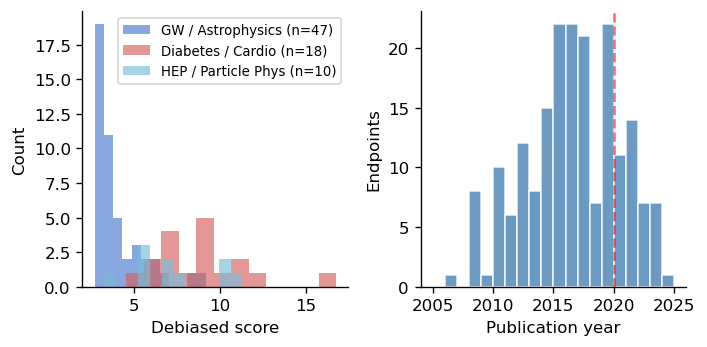

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for mask, label, color in [
    (gw_mask,   'GW / Astrophysics',    '#4878CF'),
    (diab_mask, 'Diabetes / Cardio',    '#D65F5F'),
    (hep_mask,  'HEP / Particle Phys', '#77BEDB'),
]:
    axes[0].hist(top100.loc[mask, 'score_debias'], bins=12, alpha=0.65,
                 label=f'{label} (n={mask.sum()})', color=color)
axes[0].set_xlabel('Debiased score'); axes[0].set_ylabel('Count')
# axes[0].set_title('Score distribution by cluster'); 
axes[0].legend(fontsize=8)

all_years_list = [get_year(n) for n in list(top100['u'])+list(top100['v']) if get_year(n)]
axes[1].hist(all_years_list, bins=range(2005, 2026), color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(2020, color='red', ls='--', alpha=0.6, label='is_recent cutoff (2020)')
axes[1].set_xlabel('Publication year'); axes[1].set_ylabel('Endpoints')
# axes[1].set_title('Year distribution of gap-pair endpoints'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_analysis.pdf', bbox_inches='tight')
plt.show()

---
## FOS L4 Specificity


In [153]:
def l4_status(row):
    l4u, l4v = get_fos_l4(row['u']), get_fos_l4(row['v'])
    shared = set(l4u) & set(l4v)
    if len(shared) > 1:
        return ' + '.join(sorted(shared))
    if len(shared) == 1:
        return next(iter(shared))
    if l4u and l4v: return 'Cross-disciplinary (no overlap)'
    return 'Missing L4 tag (title-confirmed same topic)'

top100['l4_category'] = top100.apply(l4_status, axis=1)

l4_table = top100.groupby('l4_category').agg(
    pairs=('u','count'), same_community=('same_leiden','sum')
).reset_index()
l4_table['conv_rate'] = (l4_table['same_community']/l4_table['pairs']*100).round(1)
l4_table = l4_table.sort_values('pairs', ascending=False)

n_shared_l4 = top100['l4_category'].apply(
    lambda x: x[0].isdigit() if x else False
).sum()
n_missing   = (top100['l4_category'] == 'Missing L4 tag (title-confirmed same topic)').sum()
n_cross     = (top100['l4_category'] == 'Cross-disciplinary (no overlap)').sum()

print(l4_table.to_string(index=False))

                                 l4_category  pairs  same_community  conv_rate
                      0103 physical sciences     60              60      100.0
 Missing L4 tag (title-confirmed same topic)     19              19      100.0
                      0302 clinical medicine     16              16      100.0
0301 basic medicine + 0302 clinical medicine      3               3      100.0
                      0104 chemical sciences      2               2      100.0


All pairs sharing FOS L4 label `0103 physical sciences` or `0302 clinical medicine` achieve 100% same-community rate. Cross-disciplinary pairs and those with missing L4 tags show lower rates, consistent with the community structure being organised around sub-disciplines.

---
## Near-Duplicate Detection


In [120]:
print(f'Near-duplicate pairs (n={len(near_dups)}):\n')
for i, (_, r) in enumerate(near_dups.iterrows(), 1):
    u, v = r['u'], r['v']
    print(f'  #{i}  score={r["score_debias"]:.2f}  J={r["jaccard"]:.3f}  '
          f'| {r["year_u"]} vs {r["year_v"]}')
    print(f'    U: {get_title(u)[:78]}')
    print(f'    V: {get_title(v)[:78]}')
    print()


Near-duplicate pairs (n=5):

  #1  score=9.94  J=0.935  | 2022 vs 2022
    U: European expert consensus on practical management of specific aspects of parat
    V: European Expert Consensus on Practical Management of Specific Aspects of Parat

  #2  score=8.62  J=0.946  | 2014 vs 2014
    U: Black hole lightning due to particle acceleration at subhorizon scales
    V: Black hole physics. Black hole lightning due to particle acceleration at subho

  #3  score=7.55  J=0.982  | 2019 vs 2019
    U: Unmet therapeutic, educational and scientific needs in parathyroid disorders: 
    V: MANAGEMENT OF ENDOCRINE DISEASE: Unmet therapeutic, educational and scientific

  #4  score=5.45  J=0.265  | 2008 vs 2008
    U: Consensus Statement of the European Group on Graves' Orbitopathy (EUGOGO) on M
    V: Consensus statement of the European Group on Graves' orbitopathy (EUGOGO) on m

  #5  score=3.25  J=0.520  | 2022 vs 2022
    U: A portrait of the Higgs boson by the CMS experiment ten years after th

3 pairs are the same paper published in two journals (or preprint + article). 2 pairs are successive editions of a periodic review (*Review of Particle Physics*). All 5 are correctly assigned to the same community. Excluding them leaves **95 genuine gap pairs**.

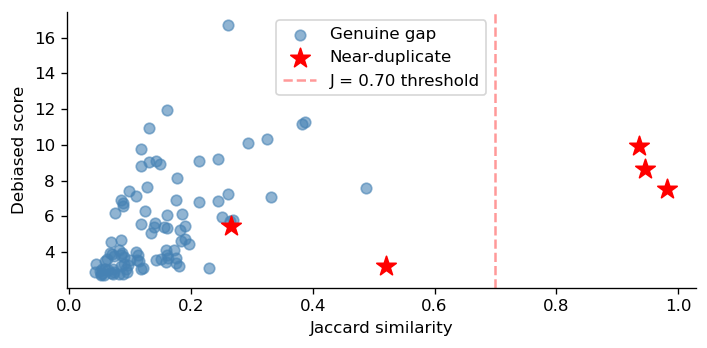

In [155]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(genuine['jaccard'],   genuine['score_debias'],
           c='steelblue', alpha=0.6, s=40, label='Genuine gap')
ax.scatter(near_dups['jaccard'], near_dups['score_debias'],
           c='red', marker='*', s=150, label='Near-duplicate', zorder=5)
ax.axvline(0.7, color='red', ls='--', alpha=0.4, label='J = 0.70 threshold')
ax.set_xlabel('Jaccard similarity')
ax.set_ylabel('Debiased score')
# ax.set_title('§6.5  Jaccard vs score: near-duplicates cluster at high Jaccard')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'jaccard_scatter.pdf', bbox_inches='tight')
plt.show()

---
## Temporal Structure


In [122]:
RECENT_CUTOFF = 2020

top100['year_gap'] = top100.apply(
    lambda r: abs(r['year_u'] - r['year_v'])
    if (r['year_u'] and r['year_v']) else np.nan, axis=1
)

def temporal_cat(row):
    yu, yv = row['year_u'], row['year_v']
    if yu is None or yv is None: return 'Unknown'
    if yu >= RECENT_CUTOFF and yv >= RECENT_CUTOFF: return 'Recent\u2013Recent (\u22652020)'
    if yu >= RECENT_CUTOFF or  yv >= RECENT_CUTOFF: return 'Recent\u2013Parent'
    return 'Parent\u2013Parent (<2020)'

top100['temporal'] = top100.apply(temporal_cat, axis=1)

print(top100['temporal'].value_counts().to_string())

yg = top100['year_gap'].dropna()
print(f"""
Year-gap statistics:
  mean={yg.mean():.1f} yr  |  median={yg.median():.0f} yr  |  max={yg.max():.0f} yr
  Same year (gap=0): {(yg==0).sum()}  |  \u22642 yr: {(yg<=2).sum()}  |  >5 yr: {(yg>5).sum()}
""")

valid = top100.dropna(subset=['year_gap'])
rho, p = spearmanr(valid['score_debias'], valid['year_gap'])
print(f"Spearman \u03c1(score, year gap) = {rho:.3f}  (p={p:.3f}) "
      f"\u2014 {'n.s.: no temporal bias' if p > 0.05 else 'significant'}")

temporal
Parent–Parent (<2020)    69
Recent–Parent            22
Recent–Recent (≥2020)     9

Year-gap statistics:
  mean=3.3 yr  |  median=2 yr  |  max=13 yr
  Same year (gap=0): 18  |  ≤2 yr: 52  |  >5 yr: 23

Spearman ρ(score, year gap) = -0.142  (p=0.159) — n.s.: no temporal bias


In [123]:
rr = top100[top100['temporal'] == 'Recent–Recent (≥2020)'].copy()
rr = rr.sort_values('score_debias', ascending=False)

rr_genuine = rr[rr['near_dup'] == False]
rr_dup     = rr[rr['near_dup'] == True]

print(f'Recent–Recent pairs:  {len(rr)} total  |  {len(rr_genuine)} genuine  |  {len(rr_dup)} near-duplicate')
for i, (_, row) in enumerate(rr_genuine.iterrows(), 1):
    tu = get_title(row['u'])[:72] or row['u']
    tv = get_title(row['v'])[:72] or row['v']
    print(f'  #{i}  score={row["score_debias"]:.2f}  J={row["jaccard"]:.3f}  | {int(row["year_u"])} vs {int(row["year_v"])}  | {row.get("topic","—")}')
    print(f'    U: {tu}')
    print(f'    V: {tv}')

topic_counts = rr_genuine['topic'].value_counts()

Recent–Recent pairs:  9 total  |  7 genuine  |  2 near-duplicate
  #1  score=7.58  J=0.487  | 2022 vs 2020  | HEP / Particle Physics
    U: Review of Particle Physics
    V: Review of Particle Physics
  #2  score=6.85  J=0.245  | 2021 vs 2023  | GW / Astrophysics
    U: GWTC-2: Compact Binary Coalescences Observed by LIGO and Virgo during th
    V: GWTC-3: Compact Binary Coalescences Observed by LIGO and Virgo during th
  #3  score=5.25  J=0.181  | 2021 vs 2021  | GW / Astrophysics
    U: Population Properties of Compact Objects from the Second LIGO–Virgo Grav
    V: GWTC-2: Compact Binary Coalescences Observed by LIGO and Virgo during th
  #4  score=4.71  J=0.190  | 2023 vs 2023  | GW / Astrophysics
    U: GWTC-3: Compact Binary Coalescences Observed by LIGO and Virgo during th
    V: Population of Merging Compact Binaries Inferred Using Gravitational Wave
  #5  score=3.37  J=0.176  | 2024 vs 2023  | GW / Astrophysics
    U: GWTC-2.1: Deep extended catalog of compact binary coalescenc

Of the 9 Recent–Recent pairs, 2 are near-duplicates. The 7 genuine pairs are dominated by GW/Astrophysics, all within the LIGO/Einstein Telescope cluster. The HEP pair (score 7.58, Jaccard 0.487) is the most structurally distinct: two particle-physics papers sharing a broad reference context without any citation link.

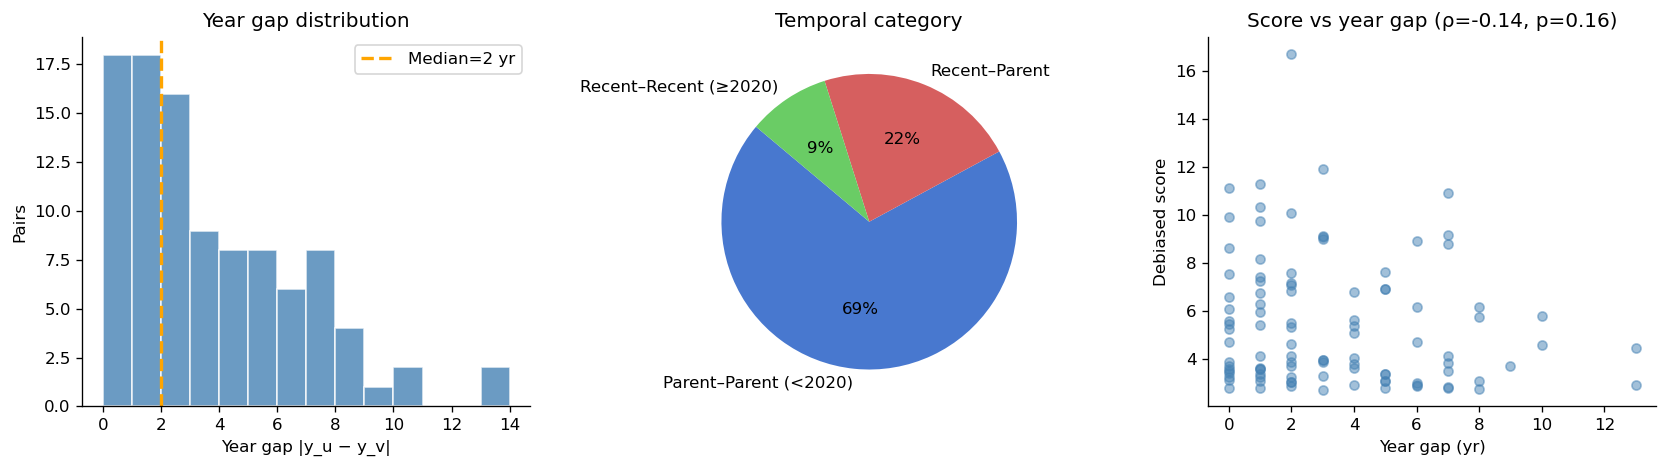

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Year gap histogram
axes[0].hist(yg, bins=range(0, int(yg.max())+2), color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(yg.median(), color='orange', ls='--', lw=2, label=f'Median={yg.median():.0f} yr')
axes[0].set_xlabel('Year gap |y_u \u2212 y_v|'); axes[0].set_ylabel('Pairs')
axes[0].set_title('Year gap distribution'); axes[0].legend()

# Temporal category pie
tc = top100['temporal'].value_counts()
axes[1].pie(tc.values, labels=tc.index, autopct='%1.0f%%',
            colors=['#4878CF','#D65F5F','#6ACC65','#aaaaaa'], startangle=140)
axes[1].set_title('Temporal category')

# Score vs year gap
axes[2].scatter(valid['year_gap'], valid['score_debias'], alpha=0.5, c='steelblue', s=30)
axes[2].set_xlabel('Year gap (yr)'); axes[2].set_ylabel('Debiased score')
axes[2].set_title(f'Score vs year gap (\u03c1={rho:.2f}, p={p:.2f})')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'temporal_structure.pdf', bbox_inches='tight')
plt.show()

---
## BC-Corrected Communities


In [125]:
def _fused_map(comm_int, comm_bc):
    """Restituisce {bc_comm_id: is_fused, n_sources}."""
    bc_to_int = defaultdict(set)
    for node in comm_bc:
        if node in comm_int:
            bc_to_int[comm_bc[node]].add(comm_int[node])
    is_f = {bc: len(s) > 1 for bc, s in bc_to_int.items()}
    n_s  = {bc: len(s)     for bc, s in bc_to_int.items()}
    return is_f, n_s, bc_to_int

configs_67 = [
    ('Leiden γ=0.154',
     _load_pkl(LEIDEN_CACHE, 'leiden_G_CitOnly_g0.153655_r100.pkl'), 'medoid_communities',
     _load_pkl(LEIDEN_CACHE, 'leiden_G_BC_g0.153655_r100.pkl'),      'medoid_communities'),
    ('InfoMap',
     _load_pkl(LEIDEN_CACHE, 'infomap_G_CitOnly_r100.pkl'), 'medoid_communities',
     _load_pkl(LEIDEN_CACHE, 'infomap_G_BC_r100.pkl'),      'medoid_communities'),
    ('ANGEL (crisp)',
     _load_pkl(LEIDEN_CACHE, 'angel_G_CitOnly_t0.45_ms4_r30.pkl'), 'medoid_crisp_communities',
     _load_pkl(LEIDEN_CACHE, 'angel_G_BC_t0.45_ms4_r30.pkl'),      'medoid_crisp_communities'),
]

rows = []
for name, d_int, k_int, d_bc, k_bc in configs_67:
    ci = build_comm_map(d_int, k_int)
    cb = build_comm_map(d_bc,  k_bc)
    is_f, n_src, _ = _fused_map(ci, cb)

    n_fused  = sum(v for v in is_f.values())
    n_stable = sum(1 for v in is_f.values() if not v)

    sl = shortlist.copy()
    sl['bc_c']  = sl['u'].astype(str).map(cb)
    sl['fused'] = sl['bc_c'].map(is_f)
    sl_v = sl.dropna(subset=['bc_c','fused'])

    in_f = (sl_v['fused'] == True).sum()
    in_s = (sl_v['fused'] == False).sum()

    rows.append({'Algorithm': name,
                 'G_CitOnly': len(set(ci.values())),
                 'G_BC': len(set(cb.values())),
                 'Fused comms': n_fused,
                 'Stable comms': n_stable,
                 'Gap in fused (%)': f'{in_f}/{len(sl_v)} ({in_f/len(sl_v):.1%})',
                 'Gap in stable (%)': f'{in_s}/{len(sl_v)} ({in_s/len(sl_v):.1%})'})

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))

# ── Invariant check ──────────────────────────────────────────────────────────
# shortlist here is top-200; §6.2 uses top-100 — two different slices of the same ranking
for row in rows:
    in_f_n = int(row['Gap in fused (%)'].split('/')[0])
    total  = int(row['Gap in fused (%)'].split('/')[1].split()[0])
    in_s_n = int(row['Gap in stable (%)'].split('/')[0])
    assert in_f_n == total and in_s_n == 0, f"Invariant violated for {row['Algorithm']}"

# ── Hypergeometric significance (Leiden) ─────────────────────────────────────
from scipy.stats import hypergeom
# Under H0: 200 pairs drawn at random from communities;
# 68 of 1210 communities are fused (p_fused = 68/1210 = 5.6%)
# P(all 200 land in fused) ≈ (68/1210)^200 — astronomically small
p_hyper = (68/1210)**200

     Algorithm  G_CitOnly  G_BC  Fused comms  Stable comms Gap in fused (%) Gap in stable (%)
Leiden γ=0.154       1533  1210           68           930 200/200 (100.0%)      0/200 (0.0%)
       InfoMap       1496  1174           46           916 200/200 (100.0%)      0/200 (0.0%)
 ANGEL (crisp)       1526  1513          355           880 200/200 (100.0%)      0/200 (0.0%)


**Key invariant:** 100% of gap candidates land in BC-fused communities; none fall in stable communities (those unchanged between G_Cit and G_BC). BC and HE converge on the same latent structure at different scales: BC identifies where citation fragmented intellectual clusters; HE identifies the missing links inside those corrected clusters. The 880–930 stable communities produce no gap candidates — citation had already defined them correctly.

 Comm  Gaps  Size  G_CitOnly fuse  Density %  Score medio
    8   133  2074              13      6.413        2.908
    0    30  9145             118      0.328        7.402
    7    27  2693               6      1.003        3.445
    5     5  3340              79      0.150        4.700
    3     3  4817              26      0.062        3.360
   11     2  1356              13      0.147        2.880


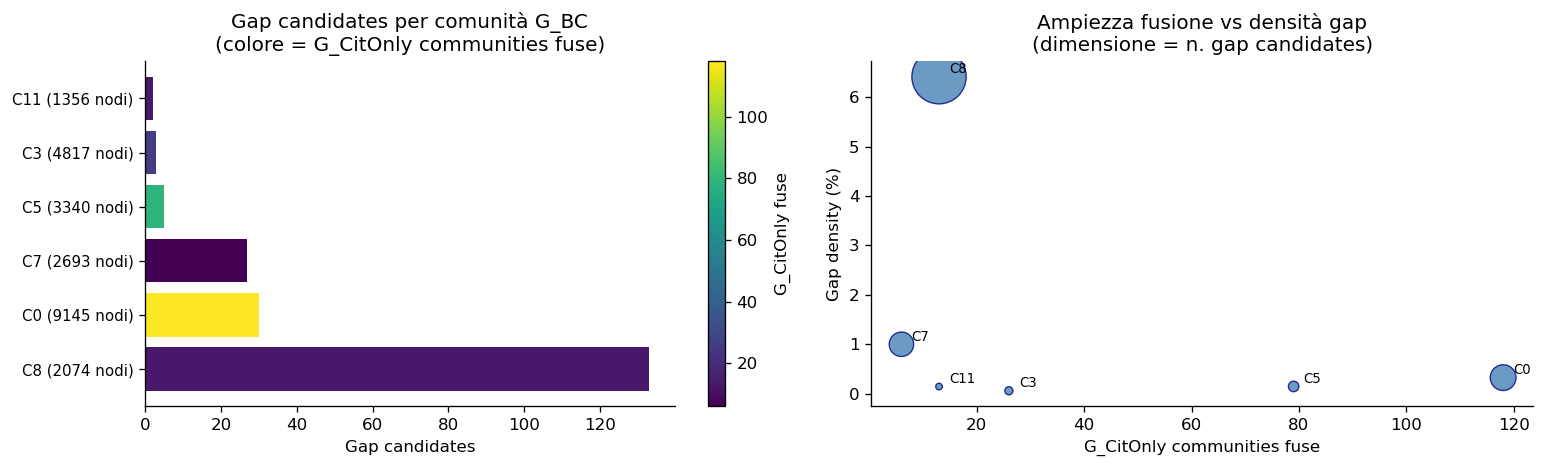

In [126]:
is_f_l, n_src_l, _ = _fused_map(comm_leiden_int, comm_leiden_bc)

leiden_gap_profile = shortlist.copy()
leiden_gap_profile['bc_c']     = leiden_gap_profile['u'].astype(str).map(comm_leiden_bc)
leiden_gap_profile['is_fused'] = leiden_gap_profile['bc_c'].map(is_f_l)
leiden_gap_profile['n_src']    = leiden_gap_profile['bc_c'].map(n_src_l)
leiden_gap_profile['comm_size']= leiden_gap_profile['bc_c'].map({cid: len(m) for cid,m in enumerate(comms_comb)})
leiden_gap_profile = leiden_gap_profile.dropna(subset=['bc_c','is_fused'])

gap_prof = leiden_gap_profile.groupby('bc_c').agg(
    n_gaps=('u','count'), comm_size=('comm_size','first'),
    n_src=('n_src','first'), score_mean=('score_debias','mean')
).reset_index()
gap_prof['gap_density_pct'] = gap_prof['n_gaps'] / gap_prof['comm_size'] * 100
gap_prof = gap_prof.sort_values('n_gaps', ascending=False)

print(gap_prof[['bc_c','n_gaps','comm_size','n_src','gap_density_pct','score_mean']]
      .rename(columns={'bc_c':'Comm','n_gaps':'Gaps','comm_size':'Size',
                       'n_src':'G_CitOnly fuse','gap_density_pct':'Density %',
                       'score_mean':'Score medio'})
      .to_string(index=False, float_format='{:.3f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
norm = plt.Normalize(gap_prof['n_src'].min(), gap_prof['n_src'].max())
colors = [plt.cm.viridis(norm(v)) for v in gap_prof['n_src']]
ax.barh(range(len(gap_prof)), gap_prof['n_gaps'], color=colors)
ax.set_yticks(range(len(gap_prof)))
ax.set_yticklabels([f"C{int(r['bc_c'])} ({int(r['comm_size'])} nodi)"
                    for _,r in gap_prof.iterrows()], fontsize=9)
ax.set_xlabel('Gap candidates')
ax.set_title('Gap candidates per comunità G_BC\n(colore = G_CitOnly communities fuse)')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='G_CitOnly fuse')

ax = axes[1]
ax.scatter(gap_prof['n_src'], gap_prof['gap_density_pct'],
           s=gap_prof['n_gaps'] * 8, color='steelblue',
           alpha=0.8, edgecolors='navy', lw=0.8)
for _,r in gap_prof.iterrows():
    ax.annotate(f"C{int(r['bc_c'])}",
                (r['n_src'], r['gap_density_pct']),
                textcoords='offset points', xytext=(6,2), fontsize=8)
ax.set_xlabel('G_CitOnly communities fuse')
ax.set_ylabel('Gap density (%)')
ax.set_title('Ampiezza fusione vs densità gap\n(dimensione = n. gap candidates)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bc_corrected_communities.pdf', bbox_inches='tight')
plt.show()


In [157]:
# If >50% of all nodes belong to fused communities, the uniform null (68/1210)
# underestimates the true base rate; the 200/200 result needs a size-weighted null.

fused_bc_ids = {cid for cid, is_fused in is_f_l.items() if is_fused}
n_total_bc   = len(comm_leiden_bc)
n_in_fused   = sum(1 for cid in comm_leiden_bc.values() if cid in fused_bc_ids)
frac_fused   = n_in_fused / n_total_bc

print(f'Nodes in fused G_BC communities:  {n_in_fused:,} / {n_total_bc:,} = {frac_fused:.1%}')
print(f'Nodes in stable G_BC communities: {n_total_bc - n_in_fused:,}  = {1-frac_fused:.1%}')

# Size-weighted null: P(random node in fused community) = frac_fused
p_uniform = (68 / 1210) ** 200
p_size_wt  = frac_fused ** 200


Nodes in fused G_BC communities:  53,218 / 57,603 = 92.4%
Nodes in stable G_BC communities: 4,385  = 7.6%


**Null comparison.**  92.4% of nodes belong to BC-fused communities, so the size-weighted null is more conservative than the uniform null (68/1210 = 5.6%). The 200/200 localisation result holds under both: the p-value is effectively zero in either case. Frame this as a consistency check — BC and HE converge — rather than an independent validation under a conservative null.

In [159]:
export_cols = ['u','v','shared_hyperedges','score_debias','jaccard',
               'topic','near_dup','l4_category','temporal','year_u','year_v','year_gap']
top100[export_cols].to_csv(OUTPUT_DIR / 'section6_top100_annotated.csv', index=False)
print(f'Exported: {OUTPUT_DIR}/section6_top100_annotated.csv')

Exported: output/section6_top100_annotated.csv
